In [12]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rishabhsnip/earth-observation-delhi-airshed/delhi_airshed.geojson
/kaggle/input/datasets/rishabhsnip/earth-observation-delhi-airshed/delhi_ncr_region.geojson
/kaggle/input/datasets/rishabhsnip/earth-observation-delhi-airshed/worldcover_bbox_delhi_ncr_2021.tif
/kaggle/input/datasets/rishabhsnip/earth-observation-delhi-airshed/rgb/28.2266_77.5234.png
/kaggle/input/datasets/rishabhsnip/earth-observation-delhi-airshed/rgb/28.4266_77.2822.png
/kaggle/input/datasets/rishabhsnip/earth-observation-delhi-airshed/rgb/28.7591_77.2058.png
/kaggle/input/datasets/rishabhsnip/earth-observation-delhi-airshed/rgb/28.5355_77.3910.png
/kaggle/input/datasets/rishabhsnip/earth-observation-delhi-airshed/rgb/28.2943_77.0234.png
/kaggle/input/datasets/rishabhsnip/earth-observation-delhi-airshed/rgb/28.6942_77.1821.png
/kaggle/input/datasets/rishabhsnip/earth-observation-delhi-airshed/rgb/28.9266_77.4321.png
/kaggle/input/datasets/rishabhsnip/earth-observation-delhi-airshed/rgb/28.2442_7

In [32]:
import pandas as pd
import geopandas as gpd
from matplotlib import pyplot as plt
import numpy as np
from shapely.geometry import Polygon, Point
import os
from collections import Counter
import torch
import torch.nn as nn
from torchvision import models
import torch.optim as optim
import seaborn as sns

In [14]:
gdf = gpd.read_file("/kaggle/input/datasets/rishabhsnip/earth-observation-delhi-airshed/delhi_ncr_region.geojson")
gdf_delhi = gdf.to_crs(epsg=32644)

In [15]:
grid_size = 60000 #in meter - 60km
xmin,ymin,xmax,ymax = gdf_delhi.total_bounds

In [16]:
grid_polys = []
for x in np.arange(xmin, xmax, grid_size):
    for y in np.arange(ymin, ymax, grid_size):
        square = Polygon([
            (x, y), 
            (x + grid_size, y), 
            (x + grid_size, y + grid_size), 
            (x, y + grid_size)
        ])
        grid_polys.append(square)

In [17]:
mesh_gdf = gpd.GeoDataFrame(geometry=grid_polys , crs="EPSG:32644")

In [18]:
len(mesh_gdf)

35

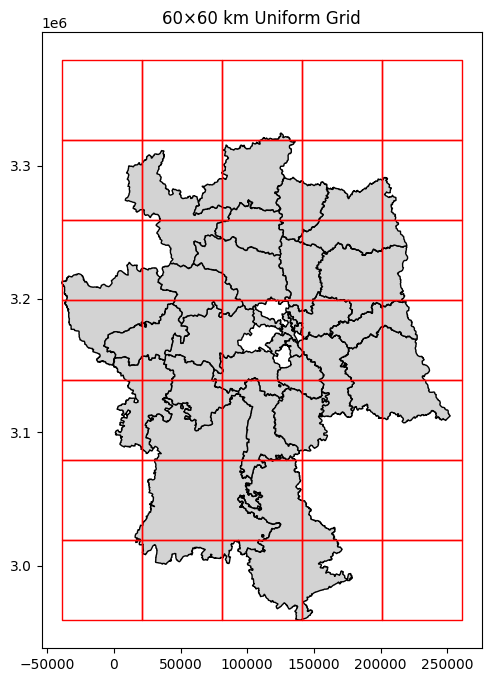

In [19]:
fig, ax = plt.subplots(figsize=(8,8))
gdf_delhi.plot(ax=ax, color="lightgrey", edgecolor="black")
mesh_gdf.plot(ax=ax, facecolor="none", edgecolor="red")

plt.title("60×60 km Uniform Grid")
plt.show()

In [20]:
image_list = os.listdir("/kaggle/input/datasets/rishabhsnip/earth-observation-delhi-airshed/rgb") 

total_before = len(image_list)


boundary = gpd.read_file('/kaggle/input/datasets/rishabhsnip/earth-observation-delhi-airshed/delhi_ncr_region.geojson') #in degree

filtered_images = []
Center_cords = []

for name in image_list:
    try:
        
        clean_name = name.replace(".png", "")
        parts = clean_name.split('_') # '_' speartes the latitude from the longitude

        lat = float(parts[0])
        lon = float(parts[1])
        
        if boundary.contains(Point(lon,lat)).any():
            filtered_images.append(name)
            Center_cords.append(Point(lon,lat))
    except:
        continue

total_after = len(filtered_images)

In [21]:
#Total number of Images Before and After
print(f"Total Before {total_before} & Total After {total_after}")

Total Before 9216 & Total After 8015


In [22]:
import rasterio
from rasterio.windows import Window
valid_images = os.listdir("/kaggle/input/datasets/rishabhsnip/earth-observation-delhi-airshed/rgb") 

landcover = rasterio.open("/kaggle/input/datasets/rishabhsnip/earth-observation-delhi-airshed/worldcover_bbox_delhi_ncr_2021.tif")

patches = []
labels= []

for img in valid_images:
    lat, lon = map(float, img.replace(".png","").split("_"))

    # raster pixel
    row, col = landcover.index(lon, lat)

    # extract 128x128 patch
    window = Window( col-64, row-64, 128, 128)
    patch = landcover.read(1, window=window)
    patches.append(patch)
    

    unique_classes, counts = np.unique(patch, return_counts=True) 
    
    max_count_index = np.argmax(counts) 

    dominant_class = unique_classes[max_count_index]

    labels.append(dominant_class)

print( {len(labels)} )

{9216}


In [23]:
esa_to_label = {
    10: "Tree_cover",         # 10
    20: "Shrubland",          # 20
    30: "Grassland",          # 30
    40: "Cropland",           # 40
    50: "Built-up",           # 50
    60: "Bare_sparse_veg",    # 60
    70: "Snow_ice",           # 70
    80: "Water",              # 80
    90: "Herbaceous_wetland", # 90
    95: "Mangroves",          # 95
    100: "Other",             # 100 or unknown -> 'Other'
}

In [24]:
simplified_labels = []
for label in labels:

    clean_text = esa_to_label.get(label, 'Others')
    
    simplified_labels.append(clean_text)
print("codes  ", labels[:10])
print("categories  ", simplified_labels[:10])

codes   [np.uint8(40), np.uint8(40), np.uint8(40), np.uint8(50), np.uint8(10), np.uint8(50), np.uint8(40), np.uint8(40), np.uint8(40), np.uint8(40)]
categories   ['Cropland', 'Cropland', 'Cropland', 'Built-up', 'Tree_cover', 'Built-up', 'Cropland', 'Cropland', 'Cropland', 'Cropland']


In [25]:
from sklearn.model_selection import train_test_split 

X_train,X_test,y_train,y_test = train_test_split(valid_images ,simplified_labels , test_size=0.4 , random_state= 42 )

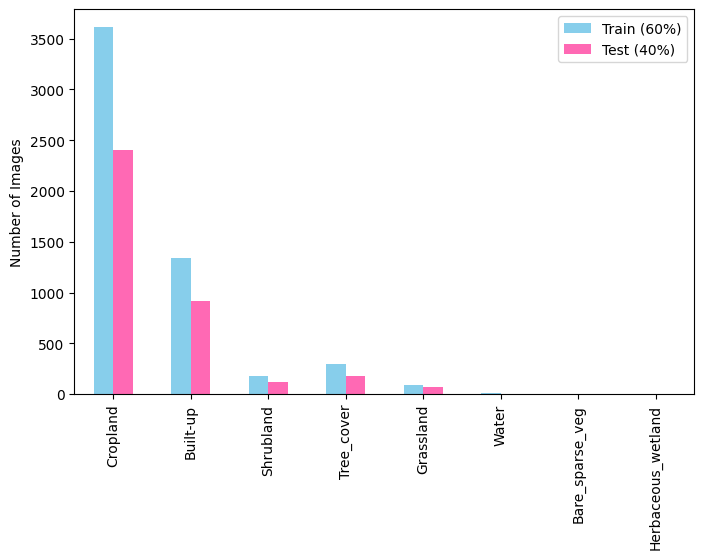

In [26]:
df = pd.DataFrame({'Train (60%)': Counter(y_train), 'Test (40%)': Counter(y_test)})

df.plot(kind='bar', figsize=(8, 5), color=['skyblue', 'hotpink'])

plt.ylabel('Number of Images')
plt.show()

In [27]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

category_to_id = {
    #vegetation 
    "Tree_cover": 1,         
    "Shrubland": 1,          
    "Grassland": 1,          
    
    #cropland  
    "Cropland": 3,           
    
    #built-up  
    "Built-up": 0,           
    
    #water  
    "Water": 2,              
    
    #others
    "Bare_sparse_veg": 4,    
    "Snow_ice": 4,           
    "Herbaceous_wetland": 4, 
    "Mangroves": 4,          
    "Other": 4               
}

image_transforms = transforms.Compose([
    transforms.ToTensor() 
])

In [28]:
class DelhiLandCoverDataset(Dataset):
    def __init__(self, image_filenames, labels, image_dir, transform):

        self.image_filenames = image_filenames
        self.labels = labels
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        img_name = self.image_filenames[idx]
        label_text = self.labels[idx]
        img_path = os.path.join(self.image_dir, img_name)
        
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
            
        label_id = category_to_id[label_text]

        return image, label_id

In [29]:
rgb_folder_path = "/kaggle/input/datasets/rishabhsnip/earth-observation-delhi-airshed/rgb"

train_dataset = DelhiLandCoverDataset(X_train, y_train, rgb_folder_path, transform=image_transforms)
test_dataset = DelhiLandCoverDataset(X_test, y_test, rgb_folder_path, transform=image_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [30]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)  #using pretrained resnet

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 5)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.002)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 203MB/s]


In [31]:
epochs = 5

for epoch in range(epochs):

    model.train() 
    total_loss = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()                
        predictions = model(images)           
        loss = criterion(predictions, labels) 
        loss.backward()                       
        optimizer.step()                      
        
        total_loss += loss.item()
        
    avg_loss = total_loss / len(train_loader)
    
    model.eval() 
    correct = 0
    total = 0
        
    with torch.no_grad(): 
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                
                outputs = model(images)
                
                prediction = torch.argmax(outputs, dim=1)

                correct += (prediction == labels).sum().item()
                total += len(labels) 
                

    accuracy = (correct / total) * 100
    print(f"Epoch {epoch+1}/{epochs} | Test Accuracy: {accuracy:.2f}%")

Epoch 1/5 | Test Accuracy: 73.42%
Epoch 2/5 | Test Accuracy: 86.90%
Epoch 3/5 | Test Accuracy: 85.90%
Epoch 4/5 | Test Accuracy: 90.86%
Epoch 5/5 | Test Accuracy: 90.62%


In [35]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

model.eval() 
predicted = []
actuals = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        guesses = torch.argmax(outputs, dim=1)
        predicted.extend(guesses.tolist())
        actuals.extend(labels.tolist())

accuracy = accuracy_score(actuals,predicted )

f1 = f1_score(actuals, predicted , average='weighted')

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"F1-Score: {f1:.2f}")

Test Accuracy: 90.62%
F1-Score: 0.91


In [40]:
cm = confusion_matrix(actuals,predicted )
categories = ['Built-up', 'Vegetation', 'Water', 'Cropland', 'Others']

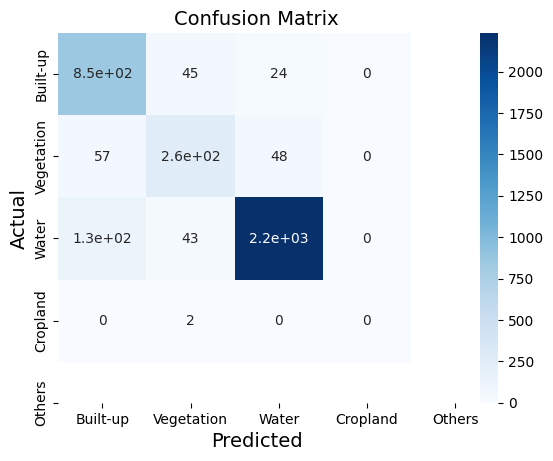

In [46]:
sns.heatmap(cm, annot=True,cmap='Blues', 
            xticklabels=categories, yticklabels=categories)

plt.xlabel('Predicted', fontsize=14)
plt.ylabel('Actual', fontsize=14)
plt.title('Confusion Matrix', fontsize=14)
plt.show()

Build up and water bodies have high True Positive but cropland and others are poorly predicted because of imbalance in data